In [1]:
import numpy as np
import os

# Find the dataset
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'unified_range_matched_peaks' in f:
 print(os.path.join(root, f))


In [2]:
import numpy as np
import os

work = '/workspace/f13040b2-bb68-46d3-ae08-776c462c6c6d'
os.chdir(work)

# Load metadata
print("function_names:", np.load('function_names.npy', allow_pickle=True))
print("k_range:", np.load('k_range.npy', allow_pickle=True))
print("N:", np.load('N.npy', allow_pickle=True))
print("n_peaks:", np.load('n_peaks.npy', allow_pickle=True))
print("t_min/t_max:", np.load('t_min.npy', allow_pickle=True), np.load('t_max.npy', allow_pickle=True))

# Inspect one Sk
sk = np.load('Sk_F1.npy', allow_pickle=True)
print("Sk_F1 shape:", sk.shape, sk.dtype)
print("amp_peaks_F1 shape:", np.load('amp_peaks_F1.npy').shape)


function_names: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
k_range: [0 1 2 3 4 5 6 7]
N: 1000000
n_peaks: 200
t_min/t_max: 10000.0 20000.0
Sk_F1 shape: (200, 8) complex128
amp_peaks_F1 shape: (200,)


In [3]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Load Sk arrays for the relevant function classes
funcs = ['F1','F2','F4','F5p','F5m','F6','F7','F9','F10','F11','F12']
Sk = {f: np.load(f'Sk_{f}.npy') for f in funcs}
for f in funcs:
 print(f, Sk[f].shape, "any nonzero S_7:", np.any(Sk[f][:,7] != 0), "any zero S_0:", np.any(Sk[f][:,0]==0))


F1 (200, 8) any nonzero S_7: True any zero S_0: False
F2 (200, 8) any nonzero S_7: False any zero S_0: False
F4 (200, 8) any nonzero S_7: False any zero S_0: False
F5p (200, 8) any nonzero S_7: False any zero S_0: False
F5m (200, 8) any nonzero S_7: False any zero S_0: False
F6 (200, 8) any nonzero S_7: True any zero S_0: False
F7 (200, 8) any nonzero S_7: True any zero S_0: False
F9 (200, 8) any nonzero S_7: True any zero S_0: False
F10 (200, 8) any nonzero S_7: True any zero S_0: False
F11 (200, 8) any nonzero S_7: True any zero S_0: False
F12 (200, 8) any nonzero S_7: False any zero S_0: False


In [4]:
# Build leak-controlled log|S_k| features for k in {1,2,3,4,5,6}
def feat(f):
 X = np.log(np.abs(Sk[f][:, 1:7]) + 1e-300)
 return X

# Core GRH-true train: F1,F2,F9,F10
train_funcs = ['F1','F2','F9','F10']
X_train = np.vstack([feat(f) for f in train_funcs])
print("X_train shape:", X_train.shape)

# Test sets
violators = ['F4','F12']
heldout_grh = ['F6','F7']
X_viol = np.vstack([feat(f) for f in violators])
X_held = np.vstack([feat(f) for f in heldout_grh])
X_insample = X_train # in-sample GRH-true

print("X_viol:", X_viol.shape, "X_held:", X_held.shape)

# Check no NaN/inf
for name, X in [('train',X_train),('viol',X_viol),('held',X_held)]:
 print(name, "finite:", np.all(np.isfinite(X)), "min:", X.min(), "max:", X.max())


X_train shape: (800, 6)
X_viol: (400, 6) X_held: (400, 6)
train finite: True min: -7.822887618191735 max: 2.196853959678806
viol finite: True min: -7.061924824813387 max: 2.825750341733348
held finite: True min: -5.132178279657478 max: 3.0286061536650526


In [5]:
# Standardize on training set, then fit OC-SVM
scaler = StandardScaler().fit(X_train)
Xtr_s = scaler.transform(X_train)
Xviol_s = scaler.transform(X_viol)
Xheld_s = scaler.transform(X_held)
Xins_s = Xtr_s # in-sample

oc = OneClassSVM(nu=0.1, gamma='scale').fit(Xtr_s)

# Decision function: higher => more "in-distribution" (GRH-true).
# For anomaly detection, anomaly score = -decision_function.
def anomaly_score(X):
 return -oc.decision_function(X)

# AUC: violators (label=1) vs held-out GRH-true (label=0)
y1 = np.concatenate([np.ones(len(X_viol)), np.zeros(len(X_held))])
s1 = np.concatenate([anomaly_score(Xviol_s), anomaly_score(Xheld_s)])
auc_held = roc_auc_score(y1, s1)

# AUC: violators vs in-sample GRH-true (control)
y2 = np.concatenate([np.ones(len(X_viol)), np.zeros(len(Xins_s))])
s2 = np.concatenate([anomaly_score(Xviol_s), anomaly_score(Xins_s)])
auc_in = roc_auc_score(y2, s2)

print(f"AUC violators vs HELD-OUT GRH-true (F4,F12 vs F6,F7): {auc_held:.4f}")
print(f"AUC violators vs IN-SAMPLE GRH-true (F4,F12 vs F1,F2,F9,F10): {auc_in:.4f}")

# Also report per-family score statistics
print("\nMean anomaly scores:")
for f in train_funcs+heldout_grh+violators:
 Xf = scaler.transform(feat(f))
 s = anomaly_score(Xf)
 print(f" {f}: mean={s.mean():.3f}, frac_outlier(score>0)={np.mean(s>0):.3f}")


AUC violators vs HELD-OUT GRH-true (F4,F12 vs F6,F7): 0.8939
AUC violators vs IN-SAMPLE GRH-true (F4,F12 vs F1,F2,F9,F10): 0.9828

Mean anomaly scores:
 F1: mean=-1.280, frac_outlier(score>0)=0.155
 F2: mean=-1.597, frac_outlier(score>0)=0.070
 F9: mean=-1.772, frac_outlier(score>0)=0.080
 F10: mean=-1.805, frac_outlier(score>0)=0.090
 F6: mean=2.009, frac_outlier(score>0)=0.665
 F7: mean=-1.890, frac_outlier(score>0)=0.100
 F4: mean=4.603, frac_outlier(score>0)=0.930
 F12: mean=6.722, frac_outlier(score>0)=0.995


In [6]:
# Per-family AUC breakdown to understand which held-out family fails
for hf in heldout_grh:
 Xh = scaler.transform(feat(hf))
 sh = anomaly_score(Xh)
 for vf in violators:
 Xv = scaler.transform(feat(vf))
 sv = anomaly_score(Xv)
 y = np.concatenate([np.ones(len(sv)), np.zeros(len(sh))])
 s = np.concatenate([sv, sh])
 print(f" {vf} vs {hf}: AUC={roc_auc_score(y,s):.4f}")


 F4 vs F6: AUC=0.7353
 F12 vs F6: AUC=0.8831
 F4 vs F7: AUC=0.9633
 F12 vs F7: AUC=0.9939


/tmp/ipykernel_20/138549863.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 bp = ax.boxplot(data, labels=[f'{f}\n({r})' for f,r in zip(order,labels_role)],


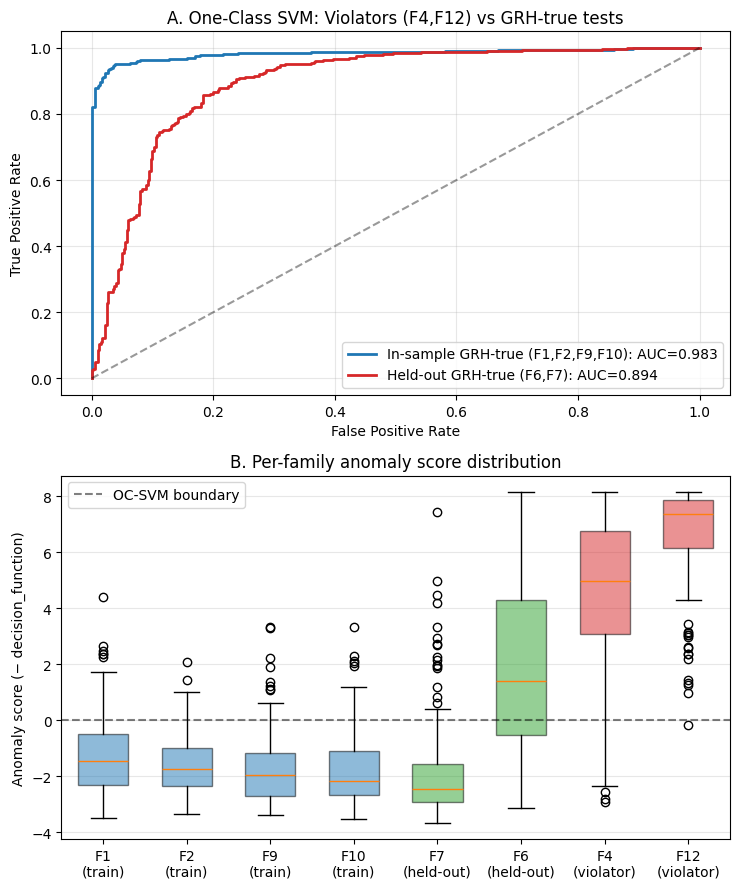

Saved figure: ocsvm_lofo_unified.png


In [7]:
# Final summary figure
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 1, figsize=(7.5, 9))

# Panel A: ROC curves
ax = axes[0]
fpr1, tpr1, _ = roc_curve(y1, s1)
fpr2, tpr2, _ = roc_curve(y2, s2)
ax.plot(fpr2, tpr2, 'C0-', lw=2, label=f'In-sample GRH-true (F1,F2,F9,F10): AUC={auc_in:.3f}')
ax.plot(fpr1, tpr1, 'C3-', lw=2, label=f'Held-out GRH-true (F6,F7): AUC={auc_held:.3f}')
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('A. One-Class SVM: Violators (F4,F12) vs GRH-true tests')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Panel B: anomaly score distribution per family
ax = axes[1]
order = ['F1','F2','F9','F10','F7','F6','F4','F12']
colors = ['C0']*4 + ['C2','C2'] + ['C3','C3']
labels_role = ['train','train','train','train','held-out','held-out','violator','violator']
data = [anomaly_score(scaler.transform(feat(f))) for f in order]
bp = ax.boxplot(data, labels=[f'{f}\n({r})' for f,r in zip(order,labels_role)],
 patch_artist=True, widths=0.6)
for patch, c in zip(bp['boxes'], colors):
 patch.set_facecolor(c); patch.set_alpha(0.5)
ax.axhline(0, color='k', ls='--', alpha=0.5, label='OC-SVM boundary')
ax.set_ylabel('Anomaly score (− decision_function)')
ax.set_title('B. Per-family anomaly score distribution')
ax.legend(loc='upper left')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ocsvm_lofo_unified.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved figure: ocsvm_lofo_unified.png")
